# Study on % of pid given in educaton

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('educ_uoe_fine06_linear.csv')
df.sample()

,DATAFLOW,LAST UPDATE,freq,unit,isced11,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
1468,ESTAT:EDUC_UOE_FINE06(1.0),07/08/25 23:00:00,Annual,Percentage of gross domestic product (GDP),Primary education,European Union - 27 countries (from 2020),2021,1.09,d,NaN


In [11]:
df["isced11"].value_counts()

isced11
Post-secondary non-tertiary education - general                                              372
Lower secondary education                                                                    364
Tertiary education (levels 5-8)                                                              363
Primary education                                                                            362
Upper secondary education                                                                    362
Upper secondary and post-secondary non-tertiary education (levels 3 and 4)                   359
Pre-primary education                                                                        357
Primary and lower secondary education (levels 1 and 2)                                       357
Post-secondary non-tertiary education - vocational                                           357
Post-secondary non-tertiary education                                                        356
Upper secondary educat

In [14]:
canonical_levels = [
    "Early childhood education",
    "Primary education",
    "Lower secondary education",
    "Upper secondary education",
    "Post-secondary non-tertiary education",
    "Tertiary education (levels 5-8)"
]

df_canonical = df[df["isced11"].isin(canonical_levels)]
total_by_country_year = (
    df_canonical.groupby(["geo", "TIME_PERIOD"])["OBS_VALUE"]
    .sum()
    .reset_index()
    .rename(columns={"OBS_VALUE": "education_pct_gdp_total"})
)

total_by_country_year.sort_values(by='education_pct_gdp_total')

,geo,TIME_PERIOD,education_pct_gdp_total
209,Liechtenstein,2018,0.00
212,Liechtenstein,2021,0.00
211,Liechtenstein,2020,0.00
210,Liechtenstein,2019,0.00
208,Liechtenstein,2017,0.00
...,...,...,...
167,Iceland,2020,8.14
265,Norway,2020,8.24
73,Denmark,2013,8.33
74,Denmark,2014,8.62


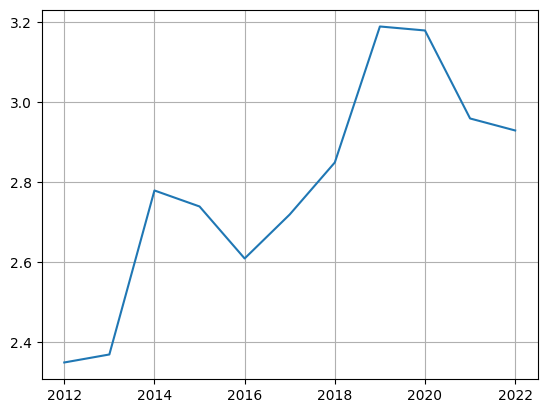

In [19]:
romania = total_by_country_year[total_by_country_year.geo == 'Romania']

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total)
plt.grid()

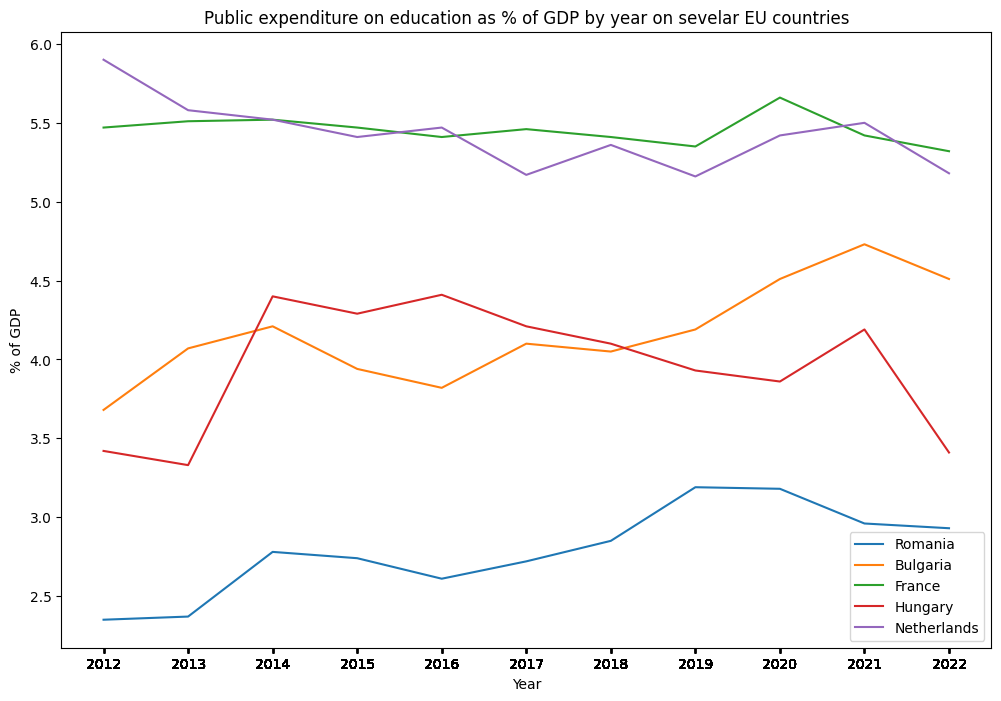

In [29]:
plt.figure(figsize=(12, 8))

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total, label='Romania')

#plot other contries total_by_country_year

Bulgaria = total_by_country_year[total_by_country_year.geo == 'Bulgaria']
plt.plot(Bulgaria.TIME_PERIOD, Bulgaria.education_pct_gdp_total, label='Bulgaria')

France = total_by_country_year[total_by_country_year.geo == 'France']
plt.plot(France.TIME_PERIOD, France.education_pct_gdp_total, label='France')

Hungary = total_by_country_year[total_by_country_year.geo == 'Hungary']
plt.plot(Hungary.TIME_PERIOD, Hungary.education_pct_gdp_total, label='Hungary')

Netherlands = total_by_country_year[total_by_country_year.geo == 'Netherlands']
plt.plot(Netherlands.TIME_PERIOD, Netherlands.education_pct_gdp_total, label='Netherlands')

plt.xticks(total_by_country_year.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on education as % of GDP by year on sevelar EU countries")
plt.legend()

This dataset goes only untill 2022, so we need to use another one

In [30]:
# link where to find the dataset: https://ec.europa.eu/eurostat/databrowser/view/gov_10a_exp/default/table

gov_spend = pd.read_csv('gov_10a_exp_linear.csv')
gov_spend.sample()

,DATAFLOW,LAST UPDATE,freq,unit,sector,cofog99,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
14362692,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Million units of national currency,State government,Foreign military aid,"Other current transfers,of which payable to su...",Belgium,2015,0.0,NaN,NaN


In [31]:
gov_spend["sector"].value_counts()

sector
General government       7759224
Central government       6975353
Local government         6884504
Social security funds    6708606
State government         6404682
Name: count, dtype: int64

In [32]:
gov_spend["cofog99"].value_counts()

cofog99
Social protection                                                          495944
Health                                                                     494811
General public services                                                    494167
Recreation, culture and religion                                           493859
Education                                                                  493476
                                                                            ...  
Economic affairs n.e.c.                                                    424179
R&D Housing and community amenities                                        424109
Public debt transactions                                                   423885
Total                                                                      422353
Transfers of a general character between different levels of government    421850
Name: count, Length: 80, dtype: int64

In [54]:
gov_spend["unit"].value_counts()

unit
Million euro                                  9986157
Percentage of gross domestic product (GDP)    9986157
Million units of national currency            9986125
Percentage of total                           4773930
Name: count, dtype: int64

In [ ]:
pib_procentage_edu = gov_spend[(gov_spend.cofog99 == 'Education') & (gov_spend.unit == 'Percentage of gross domestic product (GDP) ') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure')]
pib_procentage_edu

,DATAFLOW,LAST UPDATE,freq,unit,sector,cofog99,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
30950808,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Austria,1995,9.9,NaN,NaN
30950809,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Austria,1996,9.9,NaN,NaN
30950810,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Austria,1997,10.3,NaN,NaN
30950811,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Austria,1998,10.2,NaN,NaN
30950812,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Austria,1999,10.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
30951761,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Slovakia,2019,10.9,p,NaN
30951762,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Slovakia,2020,10.6,p,NaN
30951763,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Slovakia,2021,10.2,p,NaN
30951764,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of total,General government,Education,Total general government expenditure,Slovakia,2022,10.9,p,NaN


In [48]:
pib_procentage_edu.TIME_PERIOD.value_counts()

TIME_PERIOD
2010    33
2021    33
2019    33
2018    33
2017    33
2016    33
2015    33
2014    33
2013    33
2012    33
2011    33
2022    33
2009    33
2008    33
2007    33
2006    33
2005    33
2004    33
2003    33
2002    33
2001    33
2000    33
1999    33
1998    33
2023    33
2020    33
1995    32
1996    32
1997    32
2024     4
Name: count, dtype: int64

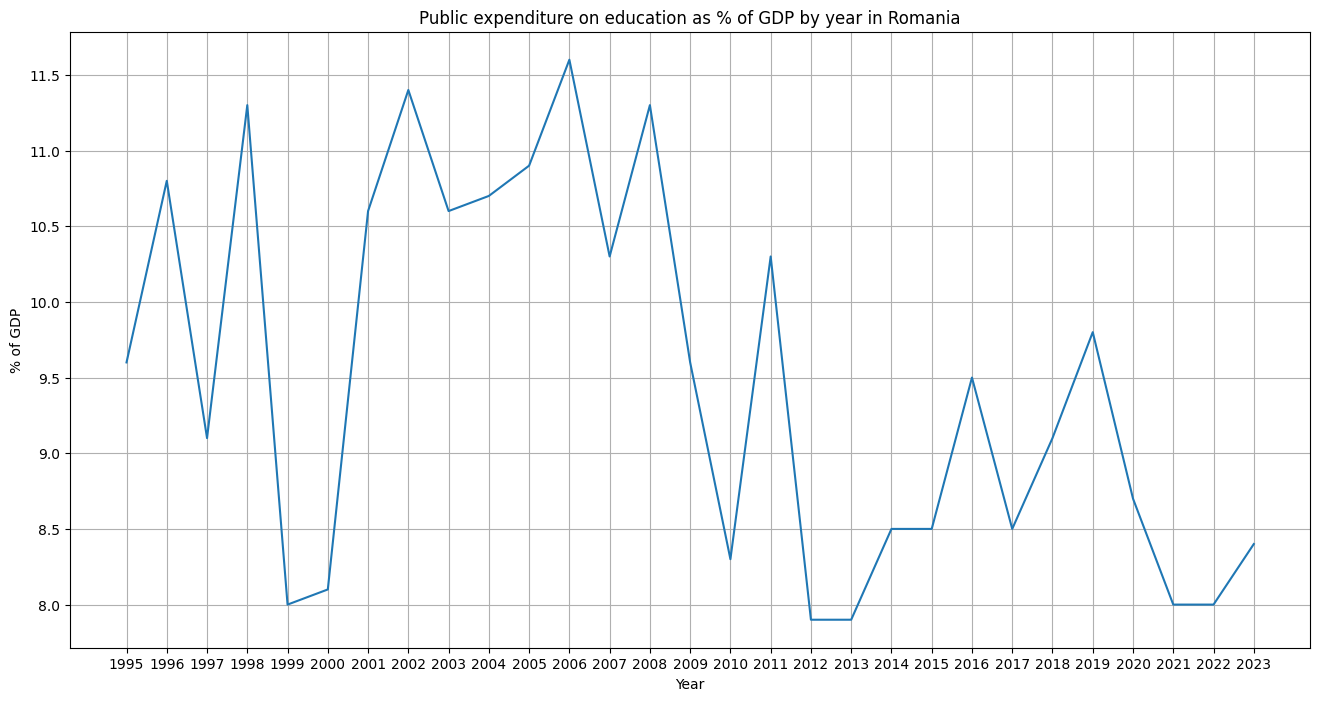

In [53]:
plt.figure(figsize=(16, 8))
romania = pib_procentage_edu[pib_procentage_edu.geo == 'Romania']

plt.plot(romania.TIME_PERIOD, romania.OBS_VALUE)

plt.xticks(romania.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on education as % of GDP by year in Romania")
plt.grid()